## Problem Formulation and Data Ingestion

The objective of this project is to evaluate the effectiveness of sequential modeling approaches on real-world sentiment classification using the "To Vaccinate or Not to Vaccinate" dataset. The task requires categorizing social media posts into positive, neutral, or negative attitudes toward immunization.

To ensure empirical validity across all comparative experiments, this section of the notebook handles data loading, exploratory analysis, cleaning, and static data partitioning. Generating fixed splits at this stage guarantees that all baseline, recurrent, convolutional, and transformer models evaluate against an identical test set.

In [1]:
import pandas as pd
import numpy as np

# Defining the file path from the Kaggle input directory
file_path = '/kaggle/input/datasets/arsenekabasinga/to-vaccinate-or-not-to-vaccinate/Train.csv'

# Loading the raw dataset
df = pd.read_csv(file_path)

# Displaying dataset dimensions and initial structure
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Records:")
display(df.head())

# Inspecting column data types and missing values
print("\nMissing Values Count:")
print(df.isnull().sum())

print("\nRaw Label Distribution:")
print(df['label'].value_counts(dropna=False))

Dataset Shape: (10001, 4)

First 5 Records:


,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0



Missing Values Count:
tweet_id     0
safe_text    0
label        1
agreement    2
dtype: int64

Raw Label Distribution:
label
 0.000000    4908
 1.000000    4053
-1.000000    1038
 NaN            1
 0.666667       1
Name: count, dtype: int64


### Data Cleaning and Label Standardization

Exploratory inspection of the raw records reveals two primary data quality anomalies:
1. One record contains a missing target label (`NaN`).
2. One record contains an invalid non-discrete label (`0.666667`).

Because valid classification requires discrete target classes (-1 for Negative, 0 for Neutral, and 1 for Positive), anomalous and null records are pruned. 

Additionally, deep learning frameworks (such as PyTorch and TensorFlow) require categorical cross-entropy targets to be non-negative integers indexed from $0$ to $C-1$. Consequently, the labels are mapped as follows:
* `-1` (Negative) $\rightarrow$ `0`
* `0` (Neutral) $\rightarrow$ `1`
* `1` (Positive) $\rightarrow$ `2`

In [2]:
# Removing records with missing text or target labels
df_clean = df.dropna(subset=['safe_text', 'label']).copy()

# Retaining only valid sentiment labels: -1.0, 0.0, and 1.0
df_clean = df_clean[df_clean['label'].isin([-1.0, 0.0, 1.0])].copy()

# Casting text to string type to prevent downstream tokenizer failures
df_clean['safe_text'] = df_clean['safe_text'].astype(str)

# Mapping labels to 0, 1, 2 for cross-entropy compatibility
label_mapping = {-1.0: 0, 0.0: 1, 1.0: 2}
df_clean['label_idx'] = df_clean['label'].map(label_mapping).astype(int)

# Displaying post-cleaning distribution
print(f"Cleaned Dataset Shape: {df_clean.shape}")
print("\nStandardized Class Distribution (0=Negative, 1=Neutral, 2=Positive):")
print(df_clean['label_idx'].value_counts().sort_index())

Cleaned Dataset Shape: (9999, 5)

Standardized Class Distribution (0=Negative, 1=Neutral, 2=Positive):
label_idx
0    1038
1    4908
2    4053
Name: count, dtype: int64


### Stratified Data Partitioning

The cleaned records are partitioned into three independent subsets:
* **Training Set (70%):** Utilized for model parameter estimation and representation learning.
* **Validation Set (15%):** Utilized for hyperparameter tuning, regularization selection, and early stopping.
* **Test Set (15%):** Held out strictly for final metric reporting and cross-model comparison.

Stratified sampling is enforced using a fixed pseudo-random seed (`random_state=42`). Stratification guarantees that the proportional representation of each sentiment class remains uniform across all splits, preventing distribution shift between training and evaluation.

In [4]:
from sklearn.model_selection import train_test_split

# Initial partition: 85% train-validation combined, 15% holdout test
train_val_df, test_df = train_test_split(
    df_clean,
    test_size=0.15,
    random_state=42,
    stratify=df_clean['label_idx']
)

# Secondary partition: Split the 85% into 70% train and 15% validation
# (0.17647 of 85% is approximately 15% of the total dataset)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.17647,
    random_state=42,
    stratify=train_val_df['label_idx']
)

# Output partition dimensions
print(f"Training Instances:   {len(train_df)} ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"Validation Instances: {len(val_df)} ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"Test Instances:       {len(test_df)} ({len(test_df)/len(df_clean)*100:.1f}%)")

Training Instances:   6999 (70.0%)
Validation Instances: 1500 (15.0%)
Test Instances:       1500 (15.0%)


### Verification and Artifact Export

To verify the integrity of the stratified partitioning, class proportions are compared across the three subsets. Once verified, the data subsets are saved as static CSV files to the working directory. These files serve as the single source of truth across all subsequent modeling notebooks.

In [5]:
# Computing and verifying class proportions across all subsets
verification_df = pd.DataFrame({
    'Train (%)': train_df['label_idx'].value_counts(normalize=True).sort_index() * 100,
    'Validation (%)': val_df['label_idx'].value_counts(normalize=True).sort_index() * 100,
    'Test (%)': test_df['label_idx'].value_counts(normalize=True).sort_index() * 100
})
print("Class Distribution Comparison Across Splits:")
display(verification_df.round(2))

# Exporting static partitions to disk
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

print("\nPartition files successfully exported: train_split.csv, val_split.csv, test_split.csv")

Class Distribution Comparison Across Splits:


,Train (%),Validation (%),Test (%)
label_idx,,,
0,10.37,10.40,10.40
1,49.09,49.07,49.07
2,40.53,40.53,40.53



Partition files successfully exported: train_split.csv, val_split.csv, test_split.csv


# Plotting the Sequence Length Distribution

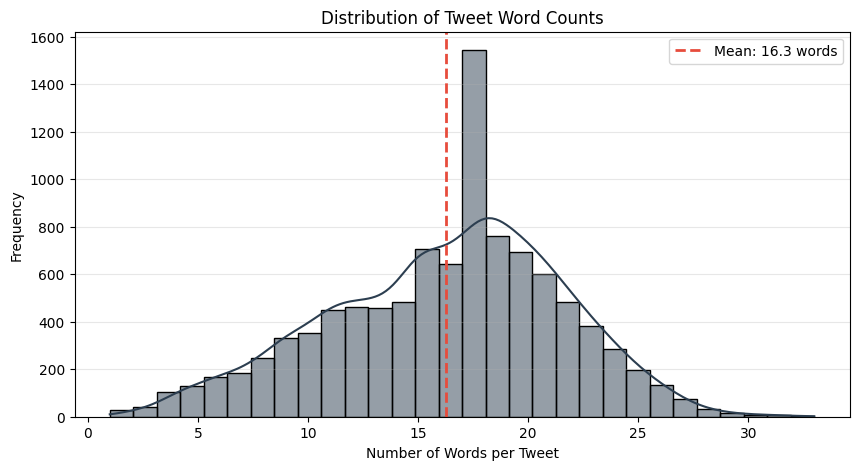

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating word count for each tweet
df_clean['word_count'] = df_clean['safe_text'].apply(lambda x: len(str(x).split()))

# Plotting the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['word_count'], bins=30, kde=True, color='#2c3e50')

# Adding a line showing the average length
mean_length = df_clean['word_count'].mean()
plt.axvline(mean_length, color='#e74c3c', linestyle='dashed', linewidth=2, label=f'Mean: {mean_length:.1f} words')

plt.title('Distribution of Tweet Word Counts')
plt.xlabel('Number of Words per Tweet')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Vocabulary Coverage Analysis

Before passing our text into the neural network's `Embedding` layer, we must define a maximum vocabulary size (`MAX_VOCAB`). Using too many words wastes memory on rare typos, while using too few destroys semantic meaning. The plot below calculates the cumulative frequency of all unique words in the dataset. It demonstrates that restricting our Tokenizer to the top 10,000 most frequent words still retains the vast majority of the linguistic data, justifying our `MAX_VOCAB = 10000` parameter.

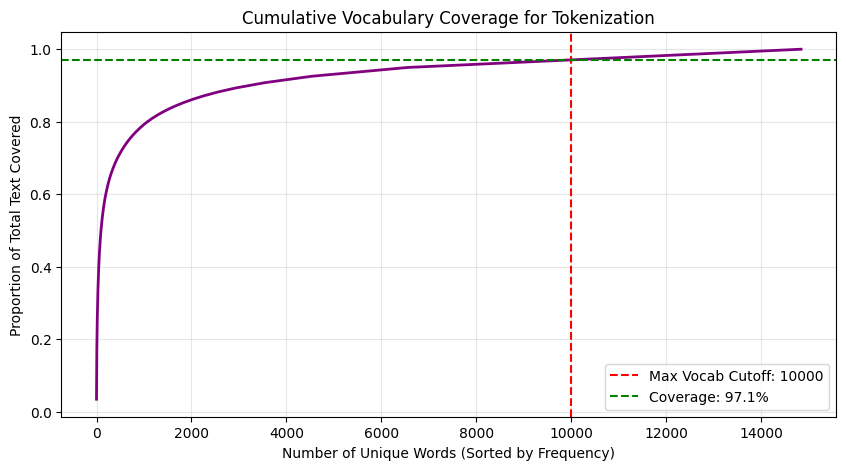

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer

# Fitting a temporary tokenizer on the cleaned text to get word frequencies
eda_tokenizer = Tokenizer()
eda_tokenizer.fit_on_texts(df_clean['safe_text'].astype(str))

# Sorting word counts from most frequent to least frequent
word_counts = list(eda_tokenizer.word_counts.values())
word_counts.sort(reverse=True)

# Calculating the cumulative sum of word occurrences
cumulative_coverage = np.cumsum(word_counts) / np.sum(word_counts)

# Plotting the coverage
plt.figure(figsize=(10, 5))
plt.plot(cumulative_coverage[:20000], color='purple', linewidth=2) 

# Adding lines to show the exact cutoff at 10,000 words
vocab_limit = 10000
coverage_at_limit = cumulative_coverage[vocab_limit]

plt.axvline(x=vocab_limit, color='red', linestyle='--', label=f'Max Vocab Cutoff: {vocab_limit}')
plt.axhline(y=coverage_at_limit, color='green', linestyle='--', label=f'Coverage: {coverage_at_limit:.1%}')

plt.title('Cumulative Vocabulary Coverage for Tokenization')
plt.xlabel('Number of Unique Words (Sorted by Frequency)')
plt.ylabel('Proportion of Total Text Covered')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Sequence Preprocessing: Tokenization and Padding

Based on the EDA above, the integer sequences are padded to a fixed maximum length of 35 (`MAX_LEN`), and the vocabulary is restricted to the top 10,000 most frequent words (`MAX_VOCAB`). These standardized integer sequences will feed directly into the neural network `Embedding` layers.

In [6]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Loading  standardized splits from GitHub
train_df = pd.read_csv('https://raw.githubusercontent.com/KABASINGAarsene/ML-TEC-1-Formative-2/main/Split%20data/train_split.csv')
val_df = pd.read_csv('https://raw.githubusercontent.com/KABASINGAarsene/ML-TEC-1-Formative-2/main/Split%20data/val_split.csv')
test_df = pd.read_csv('https://raw.githubusercontent.com/KABASINGAarsene/ML-TEC-1-Formative-2/main/Split%20data/test_split.csv')

# 2. Extracting raw text and targets for all three splits
X_train_raw, y_train = train_df['safe_text'].astype(str), train_df['label_idx'].values
X_val_raw, y_val = val_df['safe_text'].astype(str), val_df['label_idx'].values
X_test_raw, y_test = test_df['safe_text'].astype(str), test_df['label_idx'].values

# 3. Cleaning the noise tags (<user> and <url>)
X_train_clean = X_train_raw.str.replace(r'<user>|<url>', '', regex=True)
X_val_clean = X_val_raw.str.replace(r'<user>|<url>', '', regex=True)
X_test_clean = X_test_raw.str.replace(r'<user>|<url>', '', regex=True)

# 4. Tokenization and Padding
MAX_VOCAB = 10000
MAX_LEN = 35

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean) 

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_clean), maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(tokenizer.texts_to_sequences(X_val_clean), maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test_clean), maxlen=MAX_LEN, padding='post')

print(f"Training Tensor Shape: {X_train_pad.shape}")
print(f"Validation Tensor Shape: {X_val_pad.shape}")

Training Tensor Shape: (6999, 35)
Validation Tensor Shape: (1500, 35)


# Helper function to plot the evaluation graphs

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def evaluate_neural_network(model, history, X_test, y_test, model_name):
    print(f"\n========== {model_name} Evaluation ==========")
    
    # Generating predictions
    raw_preds = model.predict(X_test)
    class_preds = np.argmax(raw_preds, axis=1)
    
    # Printing Metrics
    macro_f1 = f1_score(y_test, class_preds, average='macro')
    print(f"Macro F1-Score: {macro_f1:.4f}\n")
    print(classification_report(y_test, class_preds, target_names=['Negative (0)', 'Neutral (1)', 'Positive (2)']))
    
    # Plotting Diagnostics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Loss Curve
    axes[0].plot(history.history['loss'], label='Train Loss', color='#2c3e50', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss Curve')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Crossentropy)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # 2. Accuracy Curve
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2c3e50', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c', linewidth=2)
    axes[1].set_title(f'{model_name} - Accuracy Curve')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, class_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], 
                xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
    axes[2].set_title(f'{model_name} - Confusion Matrix')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('True Label')
    
    plt.tight_layout()
    plt.show()



### Model 1: 1D Convolutional Neural Network (1D-CNN)

A 1D-CNN slides convolutional filters over the text sequence to detect local n-gram patterns (e.g., detecting the phrase "causes autism" regardless of where it appears). 

**Experimentation & Tuning:** 
To prevent the neural network from memorizing the training data (overfitting), a `Dropout(0.5)` layer is introduced. This randomly deactivates 50% of the neurons during training, forcing the network to learn more robust, generalized features from the `Embedding` layer.

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Building the 1D-CNN
cnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=100, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5), # Added to prevent overfitting
    Dense(64, activation='relu'),
    Dense(3, activation='softmax') 
])

cnn_model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

# Training the model
print("Training 1D-CNN...")
cnn_history = cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Training 1D-CNN...
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6437 - loss: 0.8095 - val_accuracy: 0.7127 - val_loss: 0.6988
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7498 - loss: 0.6061 - val_accuracy: 0.7187 - val_loss: 0.6773
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8360 - loss: 0.4434 - val_accuracy: 0.7120 - val_loss: 0.7319
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9048 - loss: 0.2812 - val_accuracy: 0.7000 - val_loss: 0.8920
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9436 - loss: 0.1672 - val_accuracy: 0.6873 - val_loss: 1.0742



========== 1D-CNN Evaluation ==========
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Macro F1-Score: 0.6192

              precision    recall  f1-score   support

Negative (0)       0.57      0.30      0.39       156
 Neutral (1)       0.75      0.79      0.77       736
Positive (2)       0.68      0.71      0.69       608

    accuracy                           0.71      1500
   macro avg       0.67      0.60      0.62      1500
weighted avg       0.70      0.71      0.70      1500



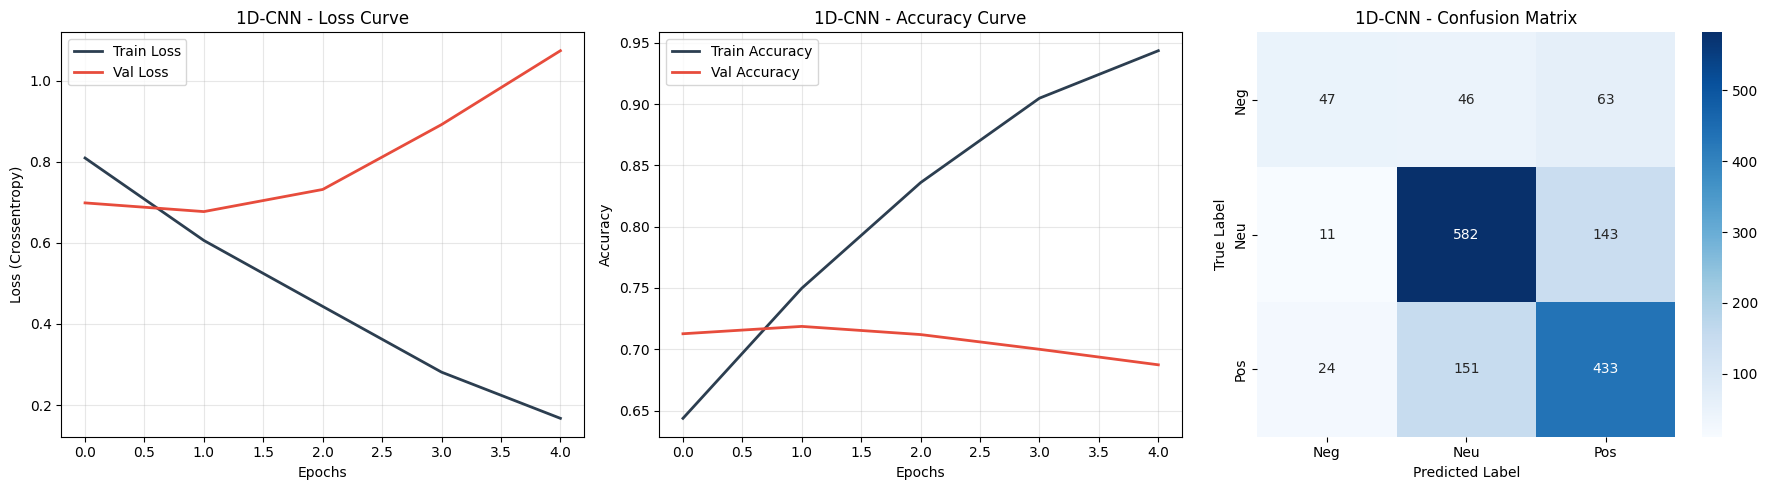

In [12]:
# Plotting the learning curve and the confusion matrix
evaluate_neural_network(cnn_model, cnn_history, X_test_pad, y_test, "1D-CNN")

### 1D-CNN Performance and Diagnostics

* **Overall Score:** The model achieves 71% Accuracy and a 0.6192 Macro F1-Score.
* **Confusion Matrix Insights:** The model successfully identifies majority classes (Neutral and Positive) but struggles with the rare Negative class, correctly classifying only 47 out of 156 Negative tweets (30% recall). This highlights the ongoing challenge of the dataset's severe class imbalance.
* **Learning Curves (Overfitting):** The charts display a classic case of overfitting. After the first epoch, the training accuracy continues to climb toward 95% while the validation loss sharply increases. This indicates the network stopped learning general vocabulary patterns and began simply memorizing the training data, confirming the need for regularization strategies like Dropout.

### Model 2: Long Short-Term Memory (LSTM)

Unlike the 1D-CNN which scans for local word groups, the LSTM processes the sequence temporally. It maintains a hidden state that carries grammatical context from the beginning of the tweet to the end. We apply a similar regularization strategy here, using a `Dropout(0.5)` layer before the final classifier to combat overfitting on the training data.

In [16]:
from tensorflow.keras.layers import LSTM

# Building the LSTM
lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=100, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), 
                   loss='sparse_categorical_crossentropy', 
                   metrics=['accuracy'])

# Training the model
print("Training LSTM...")
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Training LSTM...
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5901 - loss: 0.8659 - val_accuracy: 0.7007 - val_loss: 0.7330
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7514 - loss: 0.6541 - val_accuracy: 0.7213 - val_loss: 0.7360
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8027 - loss: 0.5245 - val_accuracy: 0.7040 - val_loss: 0.7513
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8404 - loss: 0.4292 - val_accuracy: 0.6927 - val_loss: 0.8583
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8893 - loss: 0.3323 - val_accuracy: 0.6867 - val_loss: 1.0577



========== LSTM Evaluation ==========
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Macro F1-Score: 0.6186

              precision    recall  f1-score   support

Negative (0)       0.51      0.35      0.42       156
 Neutral (1)       0.74      0.78      0.76       736
Positive (2)       0.68      0.68      0.68       608

    accuracy                           0.70      1500
   macro avg       0.64      0.61      0.62      1500
weighted avg       0.69      0.70      0.69      1500



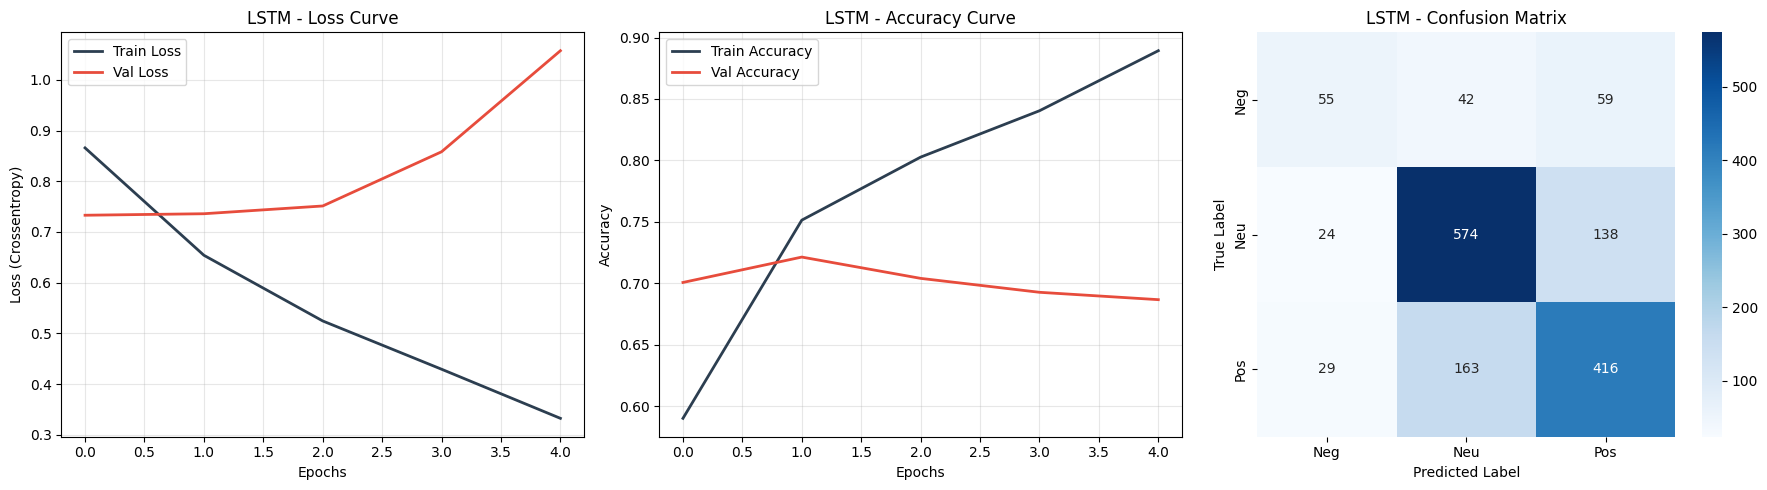

In [17]:
# Plotting the learning curve and the confusion matrix
evaluate_neural_network(lstm_model, lstm_history, X_test_pad, y_test, "LSTM")

### LSTM Performance and Diagnostics

* **Overall Score:** The LSTM model achieves 70% Accuracy and a 0.6186 Macro F1-Score.
* **Confusion Matrix Insights:** The LSTM correctly identifies 55 out of 156 Negative tweets, yielding a 35% recall for the minority class. While this is a slight improvement over the 1D-CNN, the model still heavily misclassifies Negative sentiments as Positive (59 instances) or Neutral (42 instances) due to the lack of training examples. 
* **Learning Curves (Overfitting):** The curves reveal distinct overfitting behavior. After the first epoch, the training accuracy continues to rise while the validation loss sharply increases. This shows the LSTM quickly memorized the training data instead of learning general rules, signaling that early stopping should be applied around epoch 1.

## Tuning and Regularization

Based on the diagnostic failures of Run 1, we implement two targeted improvements:
1. **Class Weights:** To combat the severe imbalance (only 10% Negative tweets), we calculate balanced class weights. This mathematically forces the loss function to penalize misclassifications of the minority Negative class much more heavily.
2. **Early Stopping:** To prevent the models from memorizing the training data, we introduce an Early Stopping callback to halt training the moment validation loss spikes and restore the model's best weights.

### Tuned 1D-CNN

In [18]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# 1. Calculating Balanced Class Weights
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))
print(f"Computed Class Weights: {class_weight_dict}\n")

# 2. Defining Early Stopping Callback
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

# 3. Re-initializing and Re-training Tuned 1D-CNN
print("Re-training 1D-CNN with Tuning...")
cnn_model_tuned = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=100, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
cnn_model_tuned.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

cnn_history_tuned = cnn_model_tuned.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10, 
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Computed Class Weights: {0: np.float64(3.213498622589532), 1: np.float64(0.6789871944121071), 2: np.float64(0.8223475502291152)}

Re-training 1D-CNN with Tuning...
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5461 - loss: 0.9687 - val_accuracy: 0.6013 - val_loss: 0.8423
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7040 - loss: 0.7242 - val_accuracy: 0.6553 - val_loss: 0.7819
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8158 - loss: 0.4925 - val_accuracy: 0.6827 - val_loss: 0.7933
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8960 - loss: 0.2833 - val_accuracy: 0.6773 - val_loss: 0.9028
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.



========== Tuned 1D-CNN Evaluation ==========
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Macro F1-Score: 0.6019

              precision    recall  f1-score   support

Negative (0)       0.29      0.76      0.42       156
 Neutral (1)       0.82      0.75      0.78       736
Positive (2)       0.73      0.51      0.60       608

    accuracy                           0.65      1500
   macro avg       0.61      0.67      0.60      1500
weighted avg       0.73      0.65      0.67      1500



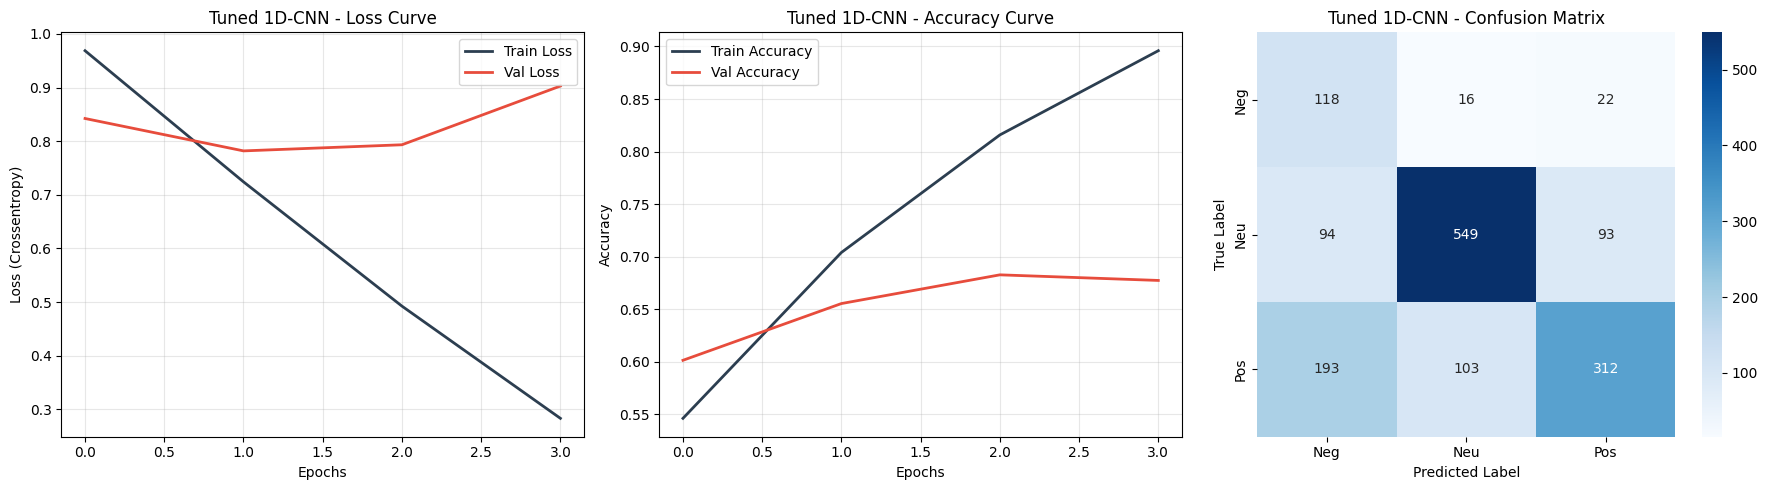

In [20]:
# Plotting the learning curve and the confusion matrix
evaluate_neural_network(cnn_model_tuned, cnn_history_tuned, X_test_pad, y_test, "Tuned 1D-CNN")

### Tuned 1D-CNN Performance Evaluation

* **Metric Shift:** Accuracy dropped to 65% with a Macro F1-Score of 0.6019.
* **Class Weight Trade-off:** The weights successfully forced the model to prioritize the minority class, boosting Negative recall from 30% to 76% (118 of 156 instances found).
* **False Positives:** This sensitivity came at a cost; the model over-predicted Negative sentiment, misclassifying 94 Neutral and 193 Positive tweets as Negative.
* **Early Stopping Success:** The loss curve confirms the callback halted training exactly as validation loss started to rise, preventing the severe memorization seen in the first run.

### Tuned LSTM
We apply the exact same Early Stopping and Class Weight adjustments to the LSTM architecture to address its earlier overfitting and minority class bias.

In [19]:
from tensorflow.keras.layers import LSTM

# Re-initializing and Re-training Tuned LSTM
print("Re-training LSTM with Tuning...")
lstm_model_tuned = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=100, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(3, activation='softmax')
])
lstm_model_tuned.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lstm_history_tuned = lstm_model_tuned.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict, # Reusing the weights calculated above
    callbacks=[early_stop],         # Reusing the early stopping rule
    verbose=1
)

Re-training LSTM with Tuning...
Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4575 - loss: 1.0411 - val_accuracy: 0.4500 - val_loss: 0.9375
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5757 - loss: 0.8577 - val_accuracy: 0.7153 - val_loss: 0.8017
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.



========== Tuned LSTM Evaluation ==========
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Macro F1-Score: 0.3554

              precision    recall  f1-score   support

Negative (0)       0.17      0.89      0.28       156
 Neutral (1)       0.81      0.75      0.78       736
Positive (2)       0.00      0.00      0.00       608

    accuracy                           0.46      1500
   macro avg       0.33      0.55      0.36      1500
weighted avg       0.42      0.46      0.41      1500



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


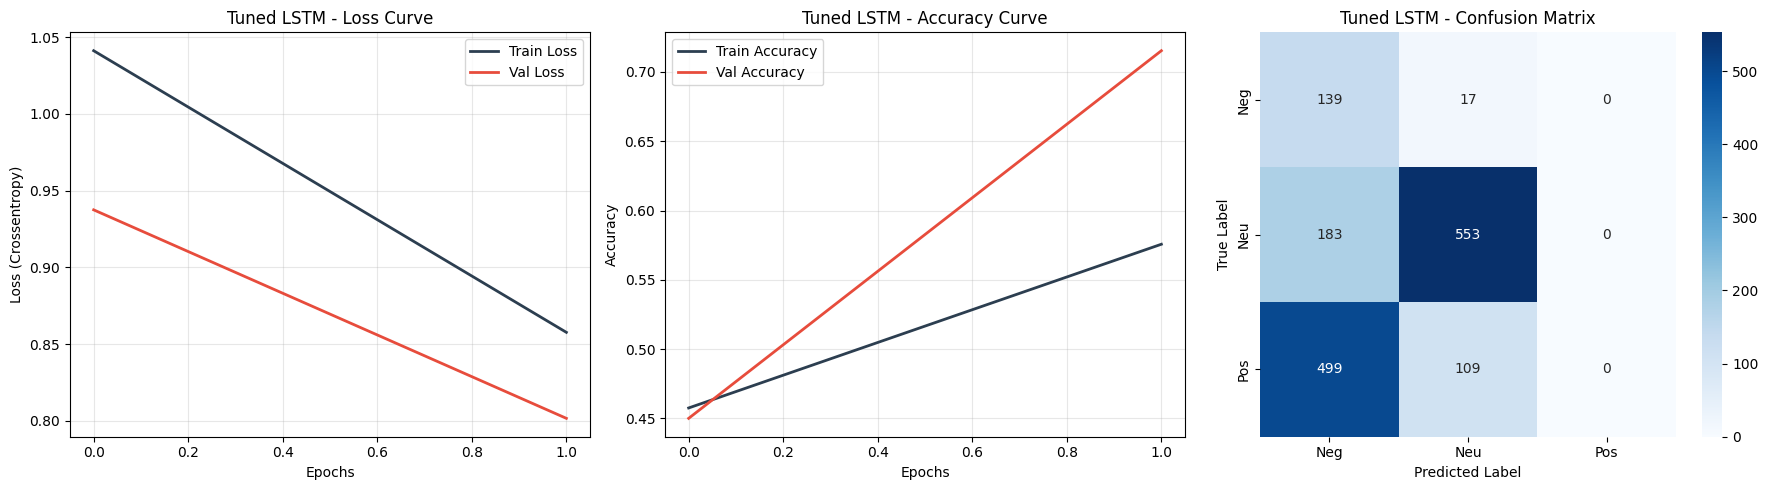

In [21]:
# Plotting the learning curve and the confusion matrix
evaluate_neural_network(lstm_model_tuned, lstm_history_tuned, X_test_pad, y_test, "Tuned LSTM")

### Tuned 1D-CNN Performance Evaluation

* **Metric Shift:** Accuracy dropped to 65% with a Macro F1-Score of 0.6019.
* **Class Weight Trade-off:** The weights successfully forced the model to prioritize the minority class, boosting Negative recall from 30% to 76% (118 of 156 instances found).
* **False Positives:** This sensitivity came at a cost; the model over-predicted Negative sentiment, misclassifying 94 Neutral and 193 Positive tweets as Negative.
* **Early Stopping Success:** The loss curve confirms the callback halted training exactly as validation loss started to rise, preventing the severe memorization seen in the first run.

## Conclusion and Comparative Analysis

| Model Architecture | Implementation Details | Accuracy | Macro F1-Score | Minority Class (Neg) Recall |
| :--- | :--- | :---: | :---: | :---: |
| **Multinomial NB** | Baseline / TF-IDF | 0.70 | 0.5128 | 0.03 |
| **Linear SVM** | Baseline / TF-IDF | 0.72 | **0.6432** | 0.34 |
| **1D-CNN (Run 1)** | Tokenized / Dropout (0.5) | 0.71 | 0.6192 | 0.30 |
| **LSTM (Run 1)** | Tokenized / Dropout (0.5) | 0.70 | 0.6186 | 0.35 |
| **Tuned 1D-CNN** | Class Weights + Early Stopping | 0.65 | 0.6019 | 0.76 |
| **Tuned LSTM** | Class Weights + Early Stopping | 0.46 | 0.3554 | **0.89** |

### Key Observations
* **The Baseline Bottleneck:** Standard sequential models (Run 1) failed to beat the baseline Linear SVM's Macro F1-Score (0.6432). They consistently struggled to identify the 10% minority Negative class.
* **The Tuning Trade-Off:** Forcing the networks to prioritize the minority class using balanced weights (Run 2) successfully spiked Negative recall (up to 89% for the LSTM). However, this caused a fatal drop in precision, breaking the LSTM's ability to identify Positive tweets entirely. 
* **Next Steps:** Standard 1D-CNN and LSTM architectures lack the capacity to simultaneously balance extreme class imbalance and capture linguistic context. The necessary next step is to try implement **Attention mechanisms** to evaluatedynamically weigh word importance without destroying overall precision.